In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
print("DATASET SHAPE:", df.shape)
print("\nCOLUMN INFORMATION:")
df.info()

DATASET SHAPE: (4000, 28)

COLUMN INFORMATION:
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_

In [5]:
print("\nFIRST 5 RECORDS:")
display(df.head())

print("\nDESCRIPTIVE STATISTICS:")
display(df.describe(include="all").T)


FIRST 5 RECORDS:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



DESCRIPTIVE STATISTICS:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.0,NaN,NaN,NaN,7.888265,4.223764,0.5,4.26,7.895,11.65,15.0
Rainfall_mm,3952.0,NaN,NaN,NaN,601.152657,288.925025,80.0,370.2,582.0,834.95,1395.2
Avg_Temperature_C,4000.0,NaN,NaN,NaN,26.8189,3.81818,16.2,23.9,26.9,29.6,39.7
Humidity_pct,4000.0,NaN,NaN,NaN,63.2105,11.960834,25.0,54.775,63.0,71.9,95.0
Sunlight_Hours_Day,4000.0,NaN,NaN,NaN,7.32305,1.121186,3.5,6.6,7.3,8.1,11.0


In [6]:
print("Duplicate rows:", df.duplicated().sum())

missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

print("\nMissing values:")
display(missing.to_frame("Missing_Count"))

Duplicate rows: 0

Missing values:


,Missing_Count
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [7]:
print("\nUnique values in major categorical columns:")
for col in ["Season", "State", "District", "Crop", "Irrigation_Method"]:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].value_counts().to_dict())
    print()


Unique values in major categorical columns:
Season: 3 unique values
{'Kharif': 1779, 'Rabi': 1627, 'Zaid': 594}

State: 8 unique values
{'Andhra Pradesh': 529, 'Telangana': 516, 'Maharashtra': 512, 'Madhya Pradesh': 497, 'Karnataka': 489, 'Gujarat': 488, 'Tamil Nadu': 485, 'Punjab': 484}

District: 10 unique values
{'Ludhiana': 427, 'Warangal': 422, 'Nalgonda': 415, 'Erode': 403, 'Rajkot': 401, 'Krishna': 393, 'Indore': 392, 'Guntur': 390, 'Raichur': 386, 'Nashik': 371}

Crop: 8 unique values
{'Rice': 690, 'Wheat': 614, 'Maize': 551, 'Cotton': 508, 'Pulses': 496, 'Groundnut': 424, 'Chilli': 412, 'Sugarcane': 305}

Irrigation_Method: 4 unique values
{'Flood': 1310, 'Rainfed': 1041, 'Drip': 915, 'Sprinkler': 734}



In [8]:
data = df.copy()

# Remove exact duplicate rows if any exist.
data = data.drop_duplicates().reset_index(drop=True)

In [9]:
numeric_cols = data.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].median())

# Clean categorical text fields.
categorical_cols = data.select_dtypes(include="object").columns
for col in categorical_cols:
    data[col] = data[col].astype(str).str.strip()

print("Rows after duplicate removal:", len(data))
print("Remaining missing values:", data.isnull().sum().sum())

display(data.head())

Rows after duplicate removal: 4000
Remaining missing values: 0


C:\Users\gomas\AppData\Local\Temp\ipykernel_17080\3902365930.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data.select_dtypes(include="object").columns


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


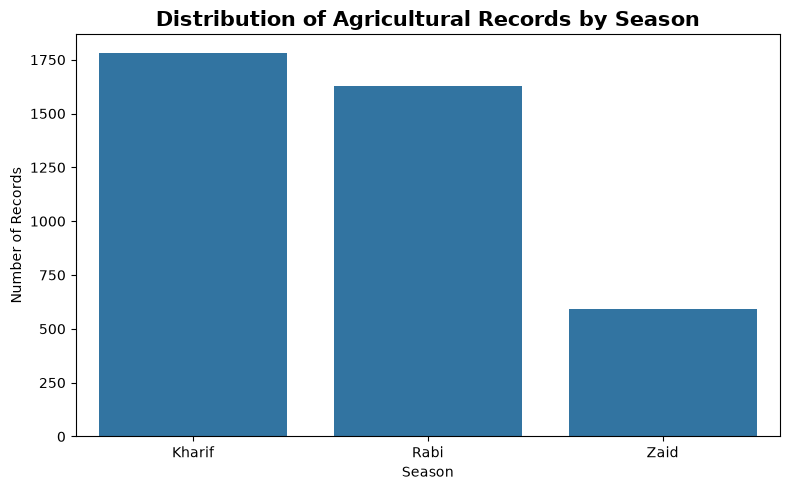

In [11]:
#SEASON DISTRIBUTION
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="Season", order=data["Season"].value_counts().index)
plt.title("Distribution of Agricultural Records by Season", fontsize=15, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

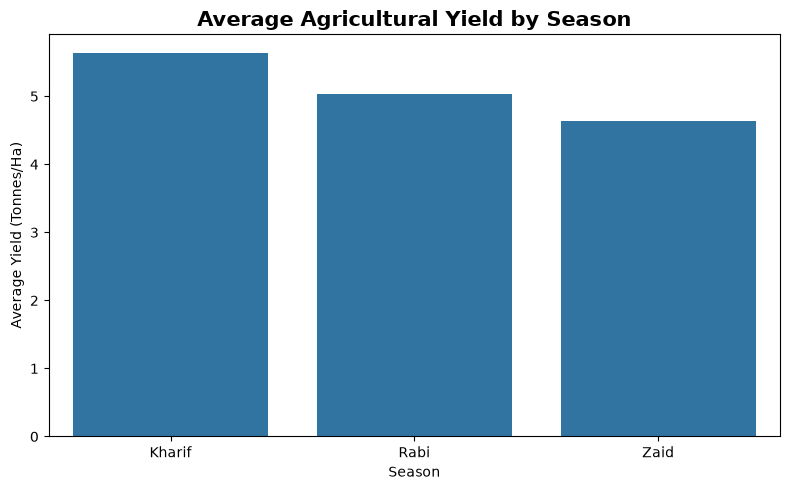

,Season,Yield_Tonnes_Ha
0,Kharif,5.628612
1,Rabi,5.039435
2,Zaid,4.641313


In [13]:
#AVERAGE YIELD BY SEASON
season_yield = data.groupby("Season", as_index=False)["Yield_Tonnes_Ha"].mean()
season_yield = season_yield.sort_values("Yield_Tonnes_Ha", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=season_yield, x="Season", y="Yield_Tonnes_Ha")
plt.title("Average Agricultural Yield by Season", fontsize=15, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

display(season_yield)

In [ ]:
# BOX PLOT — YIELD VARIATION BY SEASON
plt.figure(figsize=(9, 6))
sns.boxplot(data=data, x="Season", y="Yield_Tonnes_Ha")
sns.stripplot(
    data=data.sample(min(800, len(data)), random_state=42),
    x="Season",
    y="Yield_Tonnes_Ha",
    size=2.5,
    alpha=0.25
)
plt.title("Box Plot: Yield Distribution and Variation Across Seasons",
          fontsize=15, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

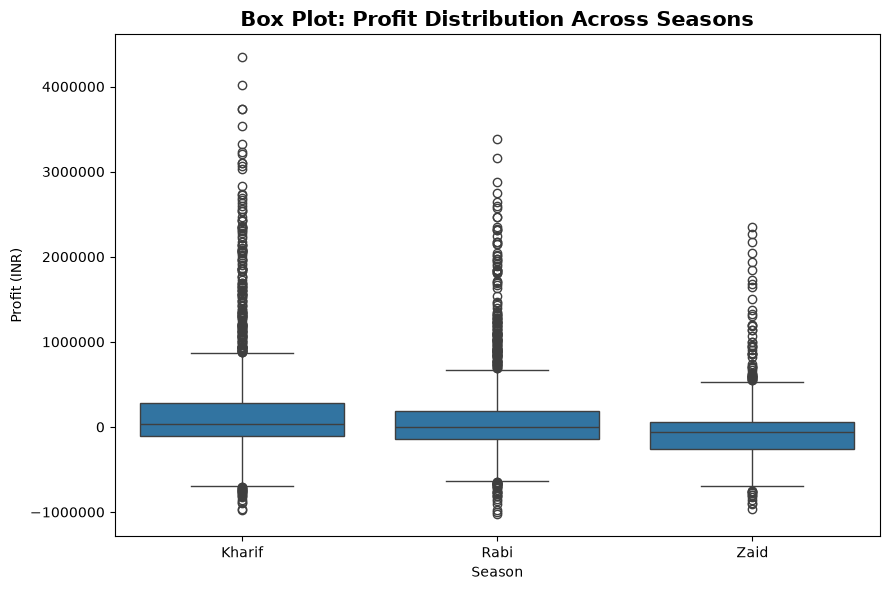

In [14]:
# BOX PLOT — PROFIT VARIATION BY SEASON
plt.figure(figsize=(9, 6))
sns.boxplot(data=data, x="Season", y="Profit_INR")
plt.title("Box Plot: Profit Distribution Across Seasons",
          fontsize=15, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


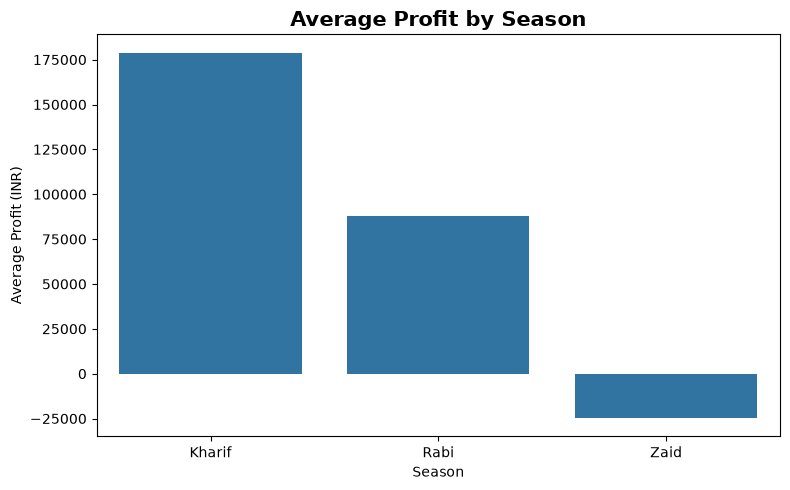

,Season,Profit_INR
0,Kharif,178914.647555
1,Rabi,87689.470191
2,Zaid,-24804.824916


In [15]:
# AVERAGE PROFIT BY SEASON
season_profit = data.groupby("Season", as_index=False)["Profit_INR"].mean()
season_profit = season_profit.sort_values("Profit_INR", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=season_profit, x="Season", y="Profit_INR")
plt.title("Average Profit by Season", fontsize=15, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()

display(season_profit)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


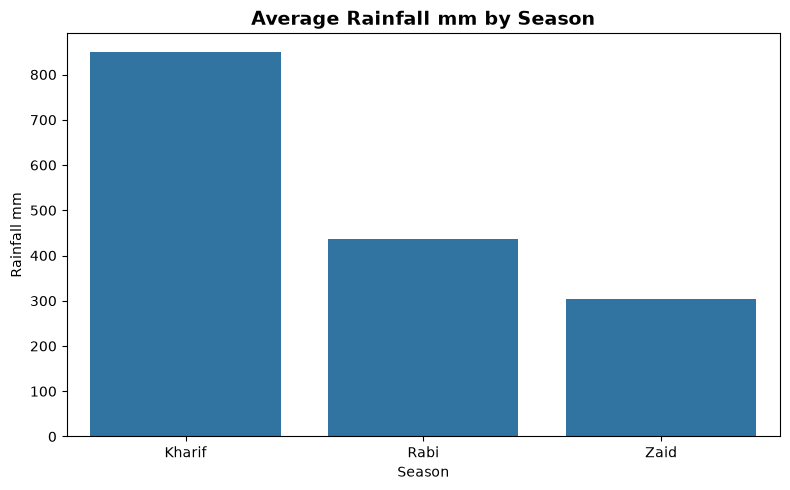

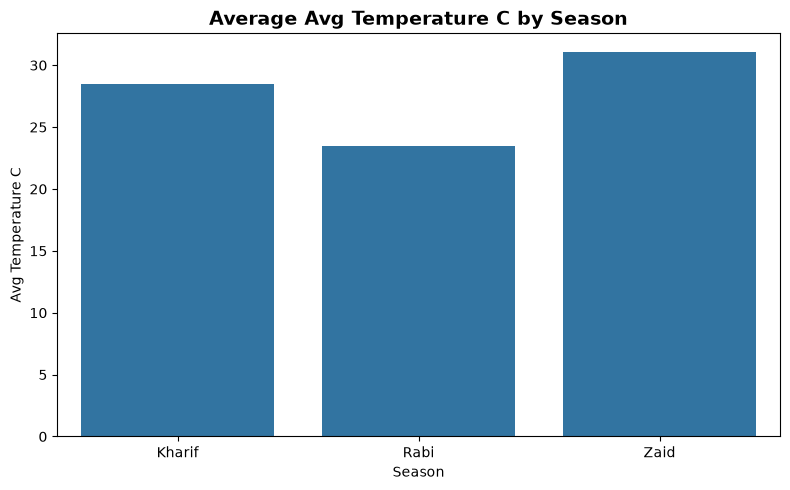

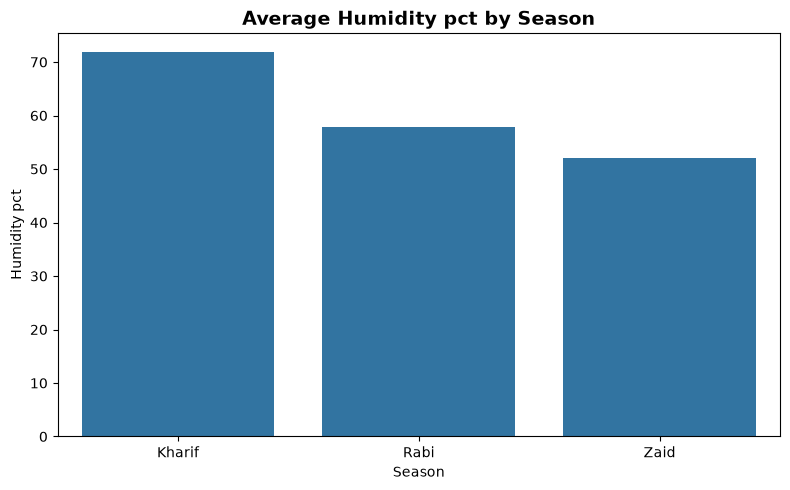

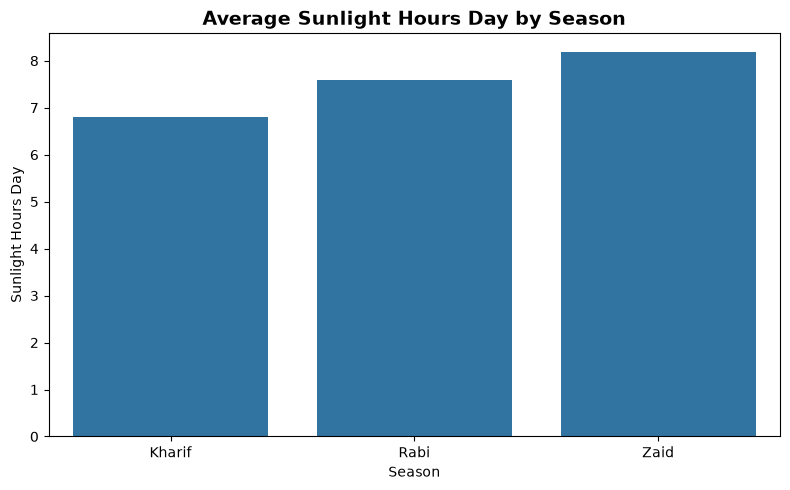

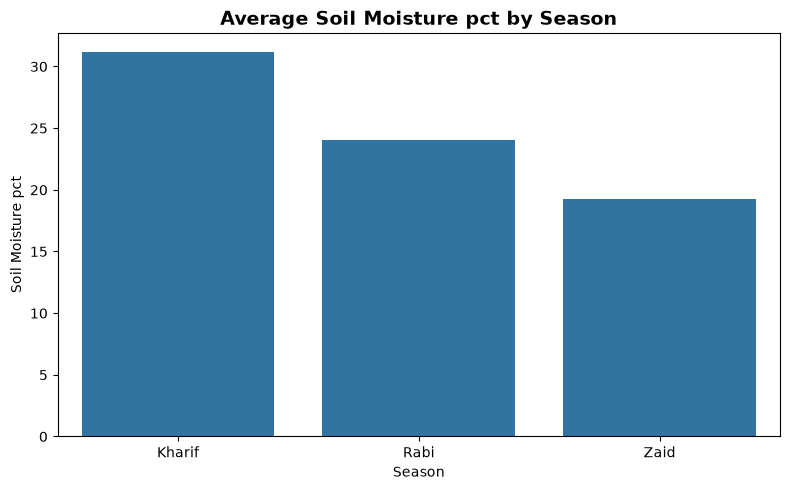

In [16]:
# ENVIRONMENTAL CONDITIONS BY SEASON
environmental_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_Moisture_pct"
]

environmental_summary = data.groupby("Season")[environmental_cols].mean().round(2)
display(environmental_summary)

# Separate plots so each chart remains readable.
for col in environmental_cols:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=data, x="Season", y=col, estimator="mean", errorbar=None)
    plt.title(f"Average {col.replace('_', ' ')} by Season",
              fontsize=14, fontweight="bold")
    plt.xlabel("Season")
    plt.ylabel(col.replace("_", " "))
    plt.tight_layout()
    plt.show()

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


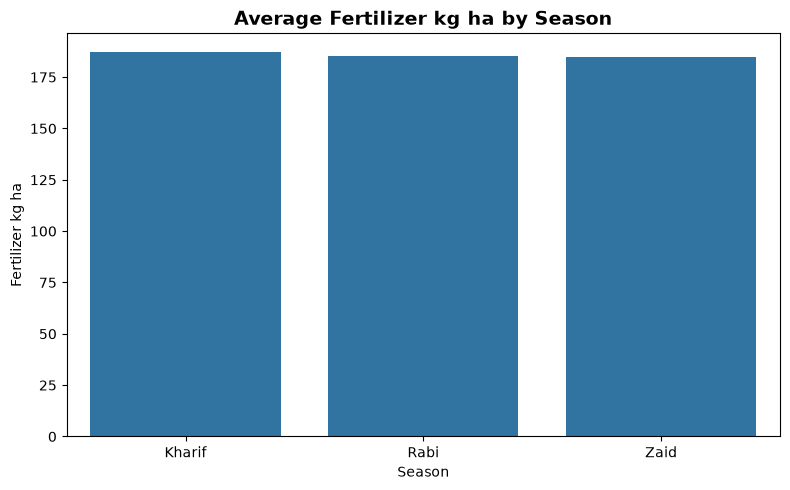

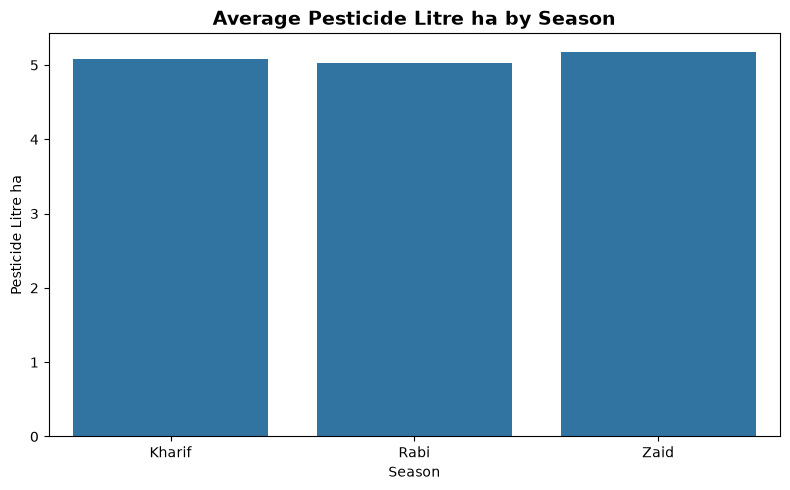

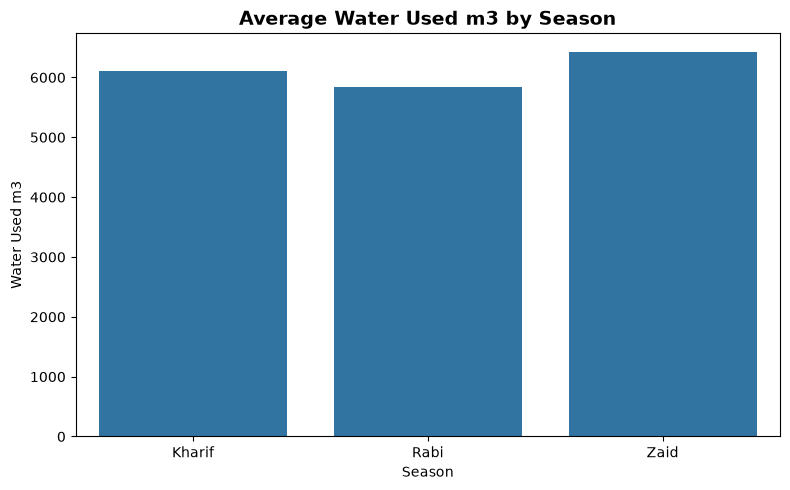

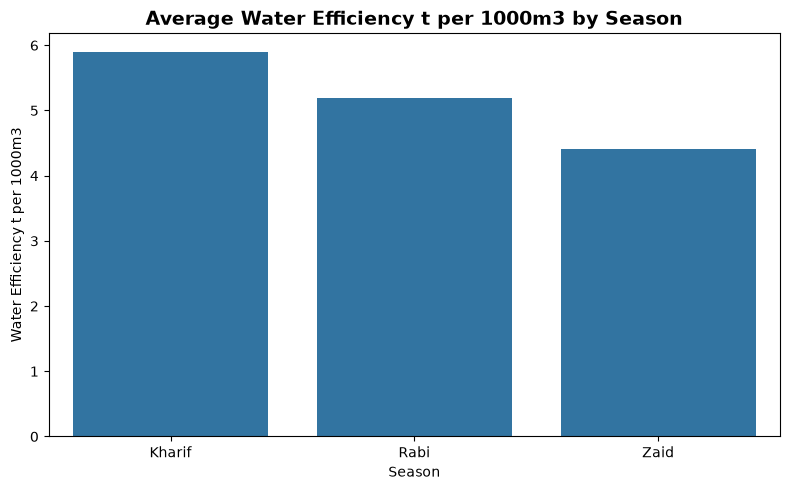

In [17]:
# RESOURCE USAGE BY SEASON
resource_cols = [
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3"
]

resource_summary = data.groupby("Season")[resource_cols].mean().round(2)
display(resource_summary)

for col in resource_cols:
    plt.figure(figsize=(8, 5))
    sns.barplot(data=data, x="Season", y=col, estimator="mean", errorbar=None)
    plt.title(f"Average {col.replace('_', ' ')} by Season",
              fontsize=14, fontweight="bold")
    plt.xlabel("Season")
    plt.ylabel(col.replace("_", " "))
    plt.tight_layout()
    plt.show()

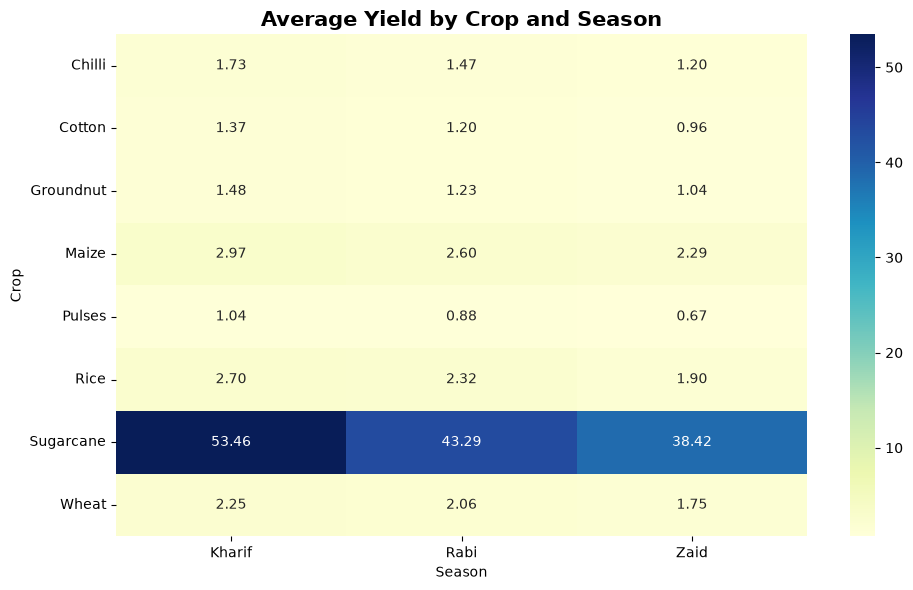

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


In [18]:
# CROP-WISE SEASONAL YIELD HEATMAP
crop_season_yield = pd.pivot_table(
    data=data,
    index="Crop",
    columns="Season",
    values="Yield_Tonnes_Ha",
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(crop_season_yield, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Average Yield by Crop and Season", fontsize=15, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

display(crop_season_yield.round(2))

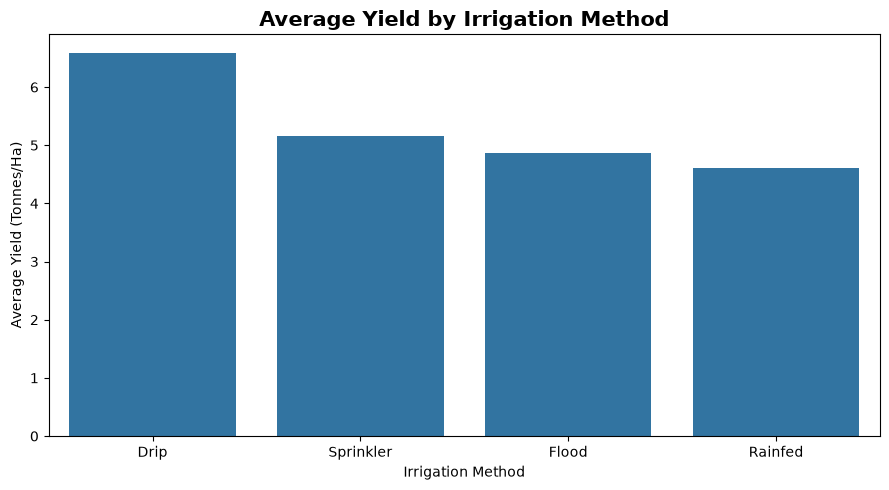

,Irrigation_Method,Yield_Tonnes_Ha
0,Drip,6.577989
3,Sprinkler,5.160627
1,Flood,4.863977
2,Rainfed,4.602142


In [19]:
# IRRIGATION METHOD VS YIELD
irrigation_yield = (
    data.groupby("Irrigation_Method", as_index=False)["Yield_Tonnes_Ha"]
    .mean()
    .sort_values("Yield_Tonnes_Ha", ascending=False)
)

plt.figure(figsize=(9, 5))
sns.barplot(data=irrigation_yield, x="Irrigation_Method", y="Yield_Tonnes_Ha")
plt.title("Average Yield by Irrigation Method", fontsize=15, fontweight="bold")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

display(irrigation_yield)


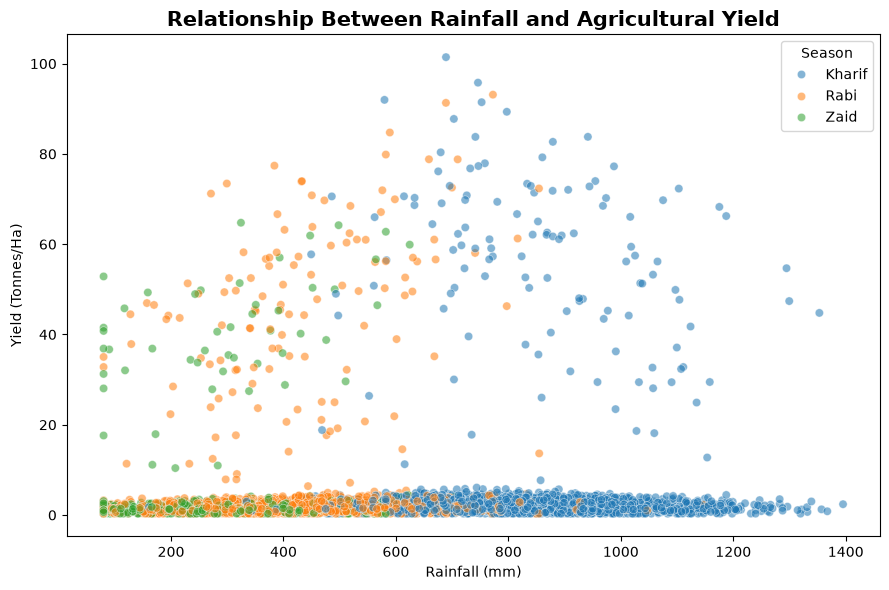

In [20]:
# SCATTER PLOT — RAINFALL VS YIELD
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=data,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.55
)
plt.title("Relationship Between Rainfall and Agricultural Yield",
          fontsize=15, fontweight="bold")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

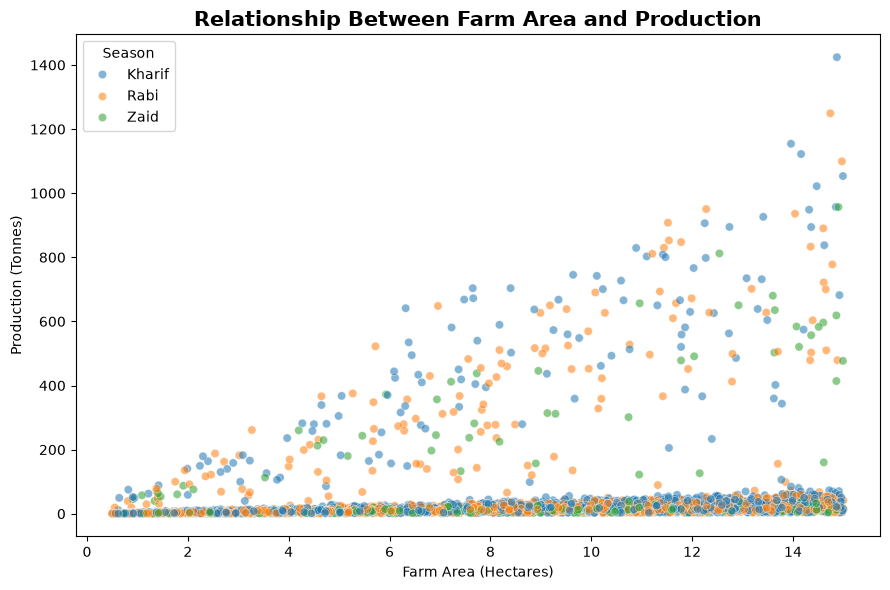

In [21]:
# SCATTER PLOT — FARM AREA VS PRODUCTION
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=data,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Season",
    alpha=0.55
)
plt.title("Relationship Between Farm Area and Production",
          fontsize=15, fontweight="bold")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()


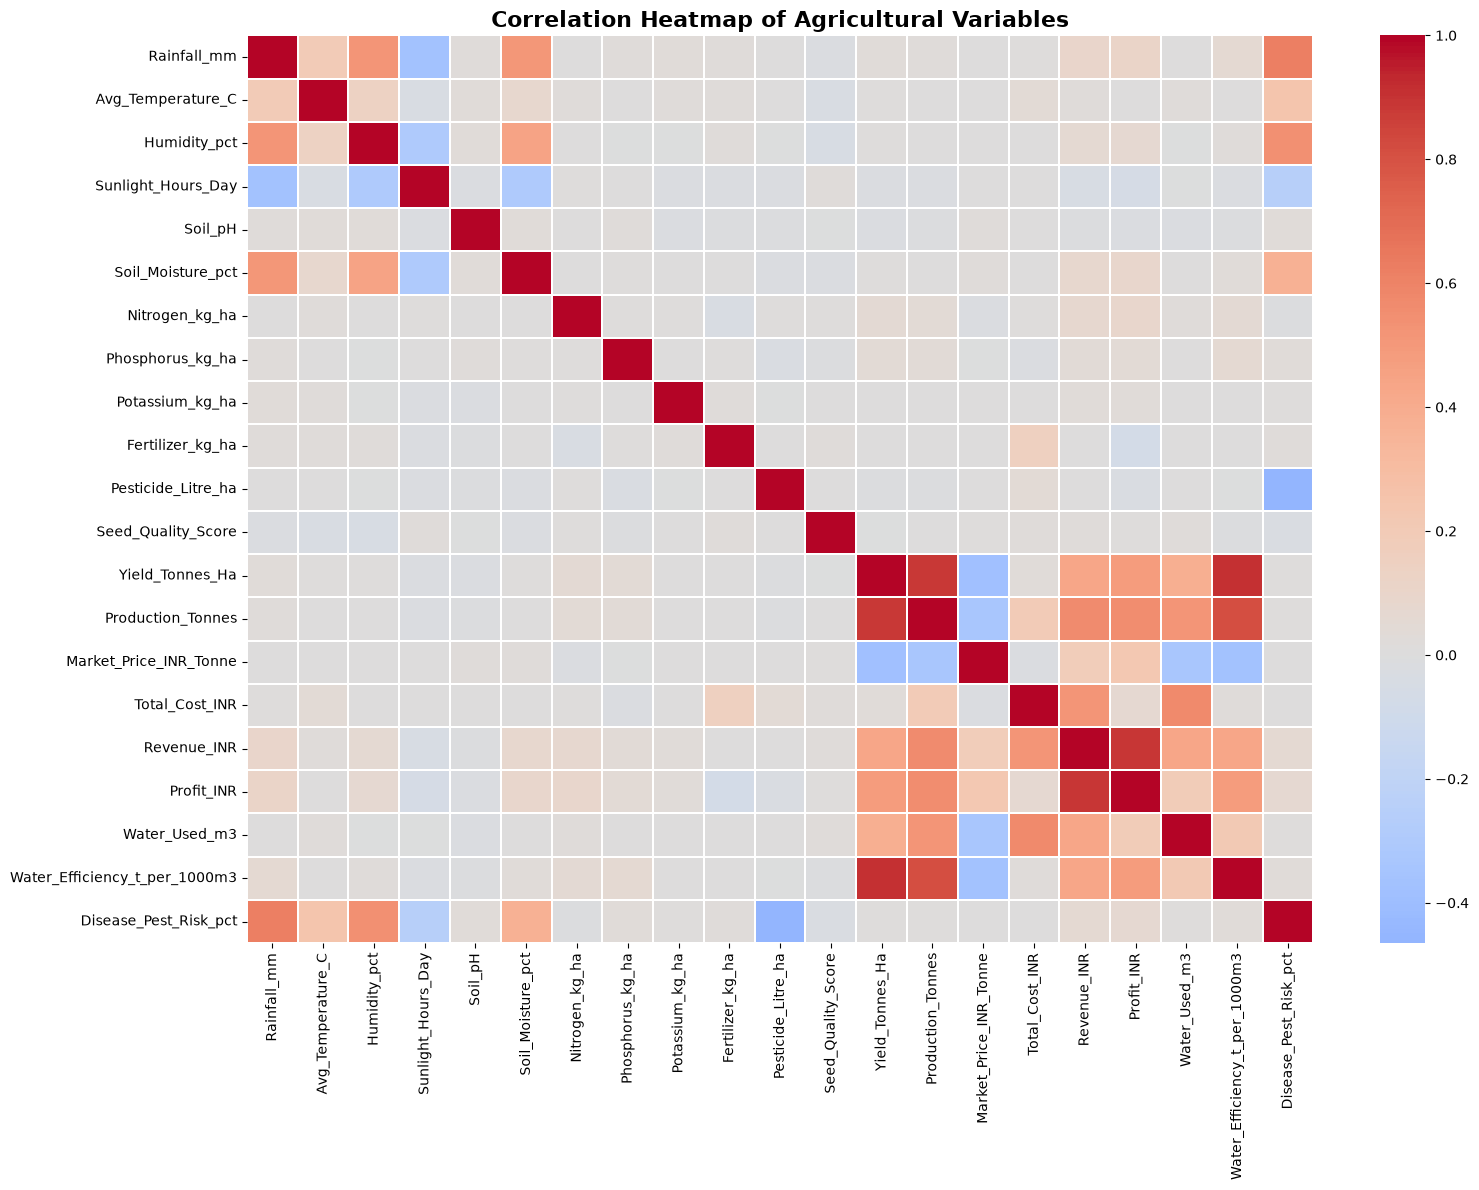

In [22]:
# CORRELATION HEATMAP
correlation_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

corr = data[correlation_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap of Agricultural Variables",
          fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


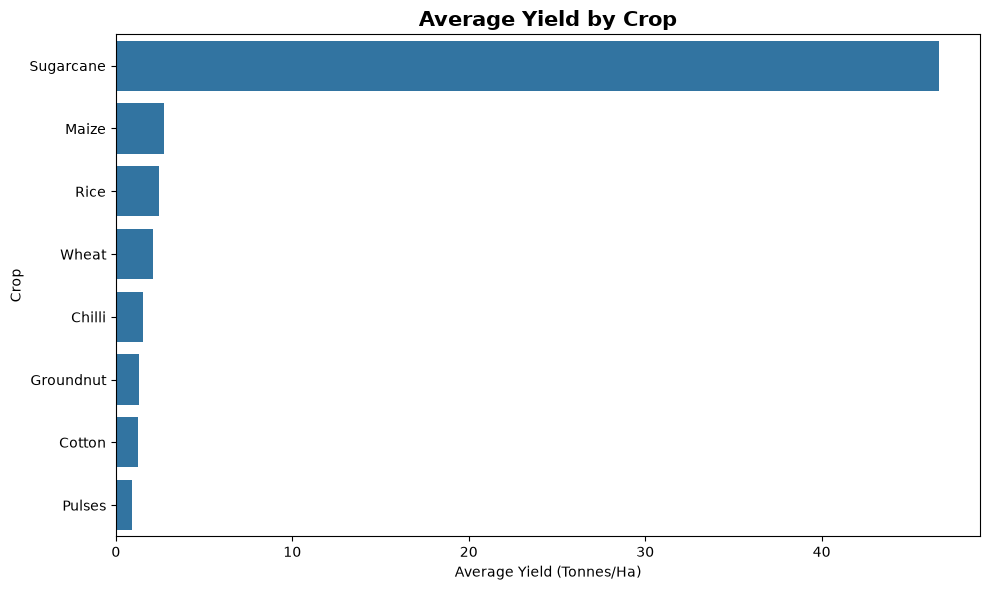

,Crop,Yield_Tonnes_Ha
6,Sugarcane,46.64
3,Maize,2.71
5,Rice,2.43
7,Wheat,2.11
0,Chilli,1.54
2,Groundnut,1.32
1,Cotton,1.23
4,Pulses,0.92


In [23]:
# TOP AND BOTTOM CROPS BY AVERAGE YIELD
crop_yield = (
    data.groupby("Crop", as_index=False)["Yield_Tonnes_Ha"]
    .mean()
    .sort_values("Yield_Tonnes_Ha", ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=crop_yield,
    x="Yield_Tonnes_Ha",
    y="Crop",
    order=crop_yield["Crop"]
)
plt.title("Average Yield by Crop", fontsize=15, fontweight="bold")
plt.xlabel("Average Yield (Tonnes/Ha)")
plt.ylabel("Crop")
plt.tight_layout()
plt.show()

display(crop_yield.round(2))

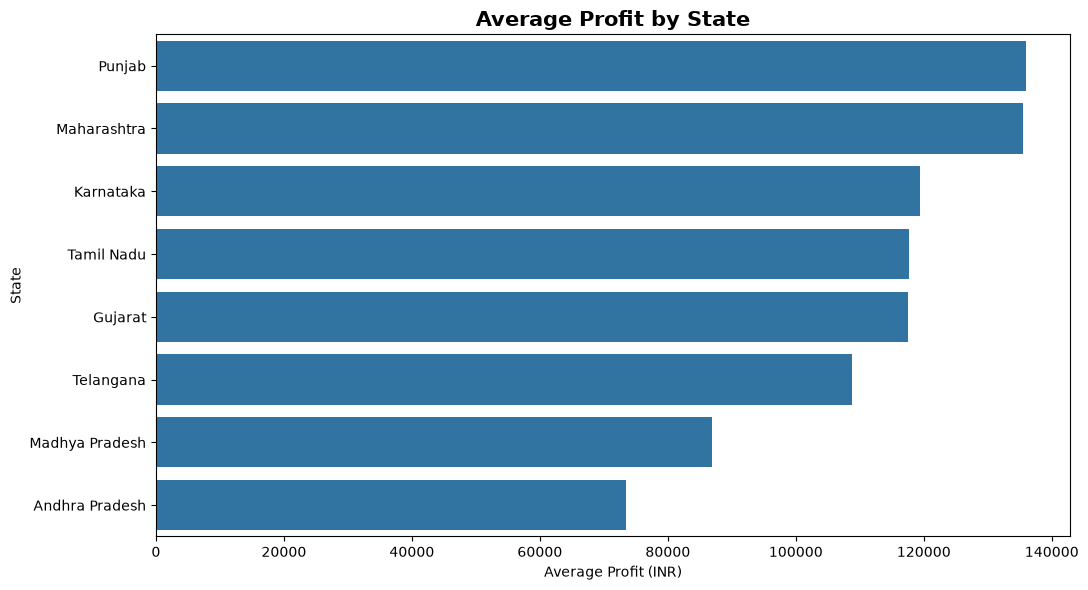

,State,Profit_INR
5,Punjab,136025.64
4,Maharashtra,135428.86
2,Karnataka,119422.34
6,Tamil Nadu,117744.75
1,Gujarat,117568.24
7,Telangana,108829.62
3,Madhya Pradesh,86840.76
0,Andhra Pradesh,73453.53


In [24]:
# STATE-WISE AVERAGE PROFIT
state_profit = (
    data.groupby("State", as_index=False)["Profit_INR"]
    .mean()
    .sort_values("Profit_INR", ascending=False)
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=state_profit,
    x="Profit_INR",
    y="State",
    order=state_profit["State"]
)
plt.title("Average Profit by State", fontsize=15, fontweight="bold")
plt.xlabel("Average Profit (INR)")
plt.ylabel("State")
plt.ticklabel_format(style="plain", axis="x")
plt.tight_layout()
plt.show()

display(state_profit.round(2))

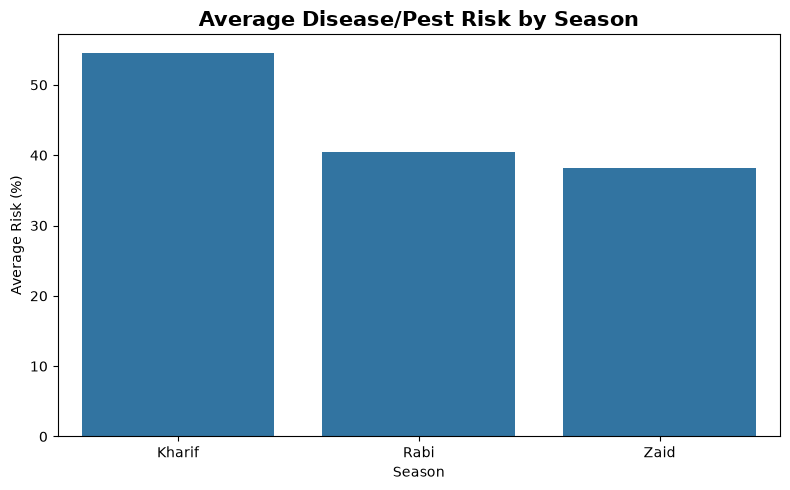

,Season,Disease_Pest_Risk_pct
0,Kharif,54.47
1,Rabi,40.48
2,Zaid,38.22


In [25]:
# DISEASE/PEST RISK BY SEASON
risk_summary = (
    data.groupby("Season", as_index=False)["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values("Disease_Pest_Risk_pct", ascending=False)
)

plt.figure(figsize=(8, 5))
sns.barplot(data=risk_summary, x="Season", y="Disease_Pest_Risk_pct")
plt.title("Average Disease/Pest Risk by Season",
          fontsize=15, fontweight="bold")
plt.xlabel("Season")
plt.ylabel("Average Risk (%)")
plt.tight_layout()
plt.show()

display(risk_summary.round(2))

In [27]:
# SEASONAL YIELD SIGNIFICANCE TESTS
from scipy import stats
season_groups = [
    group["Yield_Tonnes_Ha"].dropna().values
    for _, group in data.groupby("Season")
]

anova_stat, anova_p = stats.f_oneway(*season_groups)
kruskal_stat, kruskal_p = stats.kruskal(*season_groups)

print(f"One-way ANOVA statistic: {anova_stat:.4f}")
print(f"One-way ANOVA p-value : {anova_p:.6f}")
print()
print(f"Kruskal-Wallis statistic: {kruskal_stat:.4f}")
print(f"Kruskal-Wallis p-value : {kruskal_p:.6f}")

if anova_p < 0.05:
    print("\nInterpretation: Mean yield differs significantly across at least one pair of seasons.")
else:
    print("\nInterpretation: The analysis does not provide sufficient evidence of a significant mean-yield difference across seasons.")


One-way ANOVA statistic: 1.5439
One-way ANOVA p-value : 0.213678

Kruskal-Wallis statistic: 68.7131
Kruskal-Wallis p-value : 0.000000

Interpretation: The analysis does not provide sufficient evidence of a significant mean-yield difference across seasons.


In [28]:
# CORRELATIONS WITH KEY OUTCOMES
outcome_cols = ["Yield_Tonnes_Ha", "Profit_INR", "Water_Efficiency_t_per_1000m3"]

corr_with_outcomes = data[correlation_cols].corr()[outcome_cols].sort_values(
    by="Yield_Tonnes_Ha", ascending=False
)

print("Correlation of numeric variables with key outcomes:")
display(corr_with_outcomes.round(3))

Correlation of numeric variables with key outcomes:


,Yield_Tonnes_Ha,Profit_INR,Water_Efficiency_t_per_1000m3
Yield_Tonnes_Ha,1.000,0.488,0.913
Water_Efficiency_t_per_1000m3,0.913,0.489,1.000
Production_Tonnes,0.883,0.554,0.812
Profit_INR,0.488,1.000,0.489
Revenue_INR,0.432,0.887,0.428
Water_Used_m3,0.386,0.190,0.217
Nitrogen_kg_ha,0.053,0.085,0.055
Phosphorus_kg_ha,0.048,0.050,0.057
Rainfall_mm,0.031,0.108,0.058
Total_Cost_INR,0.031,0.068,0.020


In [29]:
# OUTLIER / UNUSUAL OBSERVATION CHECK USING IQR
def iqr_outlier_count(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return int(((series < lower) | (series > upper)).sum()), lower, upper

outlier_results = []
for col in ["Yield_Tonnes_Ha", "Profit_INR", "Water_Used_m3", "Disease_Pest_Risk_pct"]:
    count, lower, upper = iqr_outlier_count(data[col])
    outlier_results.append({
        "Variable": col,
        "Outlier_Count": count,
        "Lower_IQR_Bound": lower,
        "Upper_IQR_Bound": upper
    })

outlier_df = pd.DataFrame(outlier_results)
display(outlier_df.round(2))

,Variable,Outlier_Count,Lower_IQR_Bound,Upper_IQR_Bound
0,Yield_Tonnes_Ha,302,-1.62,5.50
1,Profit_INR,404,-696111.00,763567.00
2,Water_Used_m3,276,-6072.75,16171.25
3,Disease_Pest_Risk_pct,10,10.90,81.30


In [30]:
# FINAL SEASONAL SUMMARY TABLE
final_summary = (
    data.groupby("Season")
    .agg(
        Records=("Farm_ID", "count"),
        Avg_Yield_Tonnes_Ha=("Yield_Tonnes_Ha", "mean"),
        Avg_Production_Tonnes=("Production_Tonnes", "mean"),
        Avg_Revenue_INR=("Revenue_INR", "mean"),
        Avg_Profit_INR=("Profit_INR", "mean"),
        Avg_Water_Used_m3=("Water_Used_m3", "mean"),
        Avg_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
        Avg_Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
    )
    .sort_values("Avg_Yield_Tonnes_Ha", ascending=False)
)

display(final_summary.round(2))

,Records,Avg_Yield_Tonnes_Ha,Avg_Production_Tonnes,Avg_Revenue_INR,Avg_Profit_INR,Avg_Water_Used_m3,Avg_Water_Efficiency,Avg_Disease_Pest_Risk_pct
Season,,,,,,,,
Kharif,1779,5.63,46.31,710719.06,178914.65,6102.20,5.89,54.47
Rabi,1627,5.04,41.49,601526.05,87689.47,5846.99,5.19,40.48
Zaid,594,4.64,38.89,519171.90,-24804.82,6419.89,4.41,38.22
